In [1]:
!pip install mauve-text

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 120.9 MB/s eta 0:00:00


In [2]:
# Import key libraries

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn.functional as F

import requests
import mauve

from transformers import AutoTokenizer, AutoModelForCausalLM



In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [4]:
# Import GPT2 small and large models
gptSmall = AutoModelForCausalLM.from_pretrained("gpt2").to(device)
gptLarge = AutoModelForCausalLM.from_pretrained("gpt2-large").to(device)

gptSmall.eval()
gptLarge.eval()

# Import tokenizer
tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.set_pad_token_id = tokenizer.eos_token_id

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

# Generate data from the models

In [6]:
gptSmall_data = []
gptLarge_data = []

num_reps = 100
num_tokens = 400

# Generate 100 sequences of tokens of length 400 each
for _ in tqdm(range(num_reps)):

  # GPT-2 small
  input_ids = torch.tensor([[tokenizer.bos_token_id]]).to(device)
  attention_mask = torch.ones_like(input_ids)
  out = gptSmall.generate(
      input_ids = input_ids,
      attention_mask = attention_mask,
      pad_token_id = tokenizer.eos_token_id,
      min_length = num_tokens,
      max_length = num_tokens,
      do_sample = True,
      top_k = 50,
      top_p = 0.95,
  )
  gptSmall_data.append(out[0][1:])

  # GPT-2 Large
  input_ids = torch.tensor([[tokenizer.bos_token_id]]).to(device)
  attention_mask = torch.ones_like(input_ids)
  out = gptLarge.generate(
      input_ids = input_ids,
      attention_mask = attention_mask,
      pad_token_id = tokenizer.eos_token_id,
      min_length = num_tokens,
      max_length = num_tokens,
      do_sample = True,
      top_k = 50,
      top_p = 0.95,
  )
  gptLarge_data.append(out[0][1:])

100%|██████████| 100/100 [24:11<00:00, 14.51s/it]


# Create a list of human written texts as references (from gutenberg.org)

In [14]:
# all books have the same url format; they are unique by numerical code
baseurl='https://www.gutenberg.org/cache/epub/'

bookurls = [
    # code       title
    ['64317', 'GreatGatsby'     ],
    ['11',    'AliceWonderland' ],
    ['1513',  'RomeoJuliet'     ],
    ['76',    'HuckFinn'        ],
    ['2148',  'EdgarAllenPoe'   ],
    ['829',   'GulliversTravels']
]

mauve_scores = np.zeros((2,len(bookurls)))

xticklabels = []

for booki, (code, title) in enumerate(bookurls):
  fullurl = baseurl + code + '/pg' + code + '.txt'
  response = requests.get(fullurl)
  text = response.text

  tokens = tokenizer.encode(text, return_tensors='pt')

  xticklabels.append(title)

  # Extract random contiguous segments from each book
  ix = torch.randint(0, len(tokens[0])-num_tokens, (num_reps,1))
  human_data = tokens[0][ix + torch.arange(num_tokens)].to(device)

  # Calculate the mauve score using tokens extracted from each book as reference

  # for GPT2-small
  mauve_output = mauve.compute_mauve(
      p_tokens = gptSmall_data,       # input tokens
      q_tokens = human_data,          # reference tokens
      verbose = False,
      device_id = 0
  )
  mauve_scores[0,booki] = mauve_output.mauve


  # for GPT2-Large
  mauve_output = mauve.compute_mauve(
      p_tokens = gptLarge_data,       # input tokens
      q_tokens = human_data,          # reference tokens
      verbose = False,
      device_id = 0
  )
  mauve_scores[1,booki] = mauve_output.mauve

Featurizing p:   0%|          | 0/100 [00:00<?, ?it/s]

Featurizing q:   0%|          | 0/100 [00:00<?, ?it/s]

Featurizing p:   0%|          | 0/100 [00:00<?, ?it/s]

Featurizing q:   0%|          | 0/100 [00:00<?, ?it/s]

Featurizing p:   0%|          | 0/100 [00:00<?, ?it/s]

...

Featurizing q:   0%|          | 0/100 [00:00<?, ?it/s]

Featurizing p:   0%|          | 0/100 [00:00<?, ?it/s]

Featurizing q:   0%|          | 0/100 [00:00<?, ?it/s]

Featurizing p:   0%|          | 0/100 [00:00<?, ?it/s]

Featurizing q:   0%|          | 0/100 [00:00<?, ?it/s]

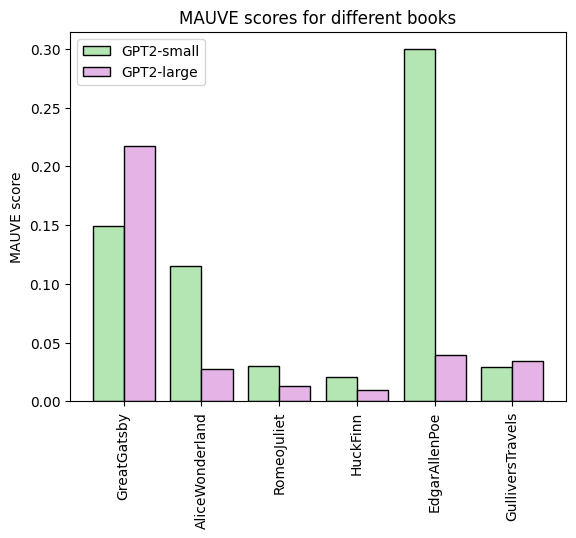

In [19]:
# Visualize the mauve scores for each model
plt.bar(np.arange(len(bookurls))-.2, mauve_scores[0,:], width=.4, facecolor=[.7,.9,.7], edgecolor='k', label='GPT2-small')
plt.bar(np.arange(len(bookurls))+.2, mauve_scores[1,:], width=.4, facecolor=[.9,.7,.9], edgecolor='k', label='GPT2-large')

ax = plt.gca()
ax.set(xticks=np.arange(len(bookurls)), ylabel='MAUVE score', title='MAUVE scores for different books')
ax.set_xticklabels(xticklabels, rotation=90)
plt.legend()
plt.show()

# Improve the model for Gulliver's travels

In [21]:
gptLarge_dataGT = []
num_prompt_tokens = 100

# Generate large tokens prompted by human text (Gulliver's Travels)
for batchi in tqdm(range(num_reps), desc="Generating tokens: GPT2-Large"):
  input_ids = human_data[batchi,:num_prompt_tokens].unsqueeze(0).to(device)
  attention_mask = torch.ones_like(input_ids)
  output = gptLarge.generate(
      input_ids = input_ids,
      attention_mask = attention_mask,
      pad_token_id = tokenizer.eos_token_id,
      min_length = num_tokens + num_prompt_tokens,
      max_length = num_tokens + num_prompt_tokens,
      do_sample = True,
      top_k = 50,
      top_p = 0.95,
  )
  gptLarge_dataGT.append(output[0,num_prompt_tokens:])

Generating tokens: GPT2-Large: 100%|██████████| 100/100 [17:38<00:00, 10.59s/it]


In [22]:
# Recalculate the MAUVE output
mauve_output = mauve.compute_mauve(
      p_tokens = gptLarge_dataGT,       # input tokens
      q_tokens = human_data,            # reference tokens
      verbose = False,
      device_id = 0
  )

print(f'Naive MAUVE score: {mauve_scores[1,-1]:.3f}')
print(f'Prompted MAUVE score: {mauve_output.mauve:.3f}')

Featurizing p:   0%|          | 0/100 [00:00<?, ?it/s]

Featurizing q:   0%|          | 0/100 [00:00<?, ?it/s]

Naive MAUVE score: 0.034
Prompted MAUVE score: 0.943
